# EXPLORATORY DATA ANALYSIS (EDA) NOTEBOOK

This Jupyter Notebook performs a complete exploratory analysis of all datasets used in the FitCoach AI project. I examine the distribution of classes, the balance between correct and incorrect executions, and the statistical properties of the keypoint sequences. I also generate visualisations that later appear in the final paper. This EDA helps me make informed modelling decisions, such as using class weights for the imbalanced general dataset or keeping a simple architecture for the perfectly balanced rehabilitation dataset.

In [110]:
# I import all the libraries I need for data manipulation, visualisation, and
# for loading the custom modules I wrote for the project.
import os
import sys
import json
import pickle
import csv
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from tqdm.auto import tqdm
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# I locate the project root directory. The notebook must be run from a location
# where the "src" and "data" folders are visible.
workspace_root = Path(r"c:\FitCoachProj")
cwd = Path.cwd().resolve()
candidates = [workspace_root, cwd, *cwd.parents]
project_root = next((p for p in candidates if (p / "src").is_dir() and (p / "data").is_dir()), None)

if project_root is None:
    raise RuntimeError("I did not find the 'src' folder. I must open this notebook from the project root.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# I import the central configuration and the exercise class definitions.
from src.utils.config import (
    EXERCISE_CLASSES, RANDOM_SEED
)

# I define the paths to the raw and processed data, and to the models directory.
RAW_DATA_DIR = project_root / "data" / "raw"
PROCESSED_DATA_DIR = project_root / "data" / "processed"
MODELS_DIR = project_root / "models"

# I set up matplotlib for inline plotting and choose a clean visual style.
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# I define a helper function to display Plotly figures inside the notebook and
# optionally save them as HTML files.
def show_plot(fig, filename=None):
    if filename is not None:
        fig.write_html(str(filename), include_plotlyjs='cdn')
    display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

# I create a folder to store all the figures generated by this EDA notebook.
EDA_FIG_DIR = MODELS_DIR / "plots" / "eda_notebook"
EDA_FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root detected: {project_root}")
print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Processed data directory: {PROCESSED_DATA_DIR}")
print(f"Figures will be saved in: {EDA_FIG_DIR}")

Project root detected: c:\FitCoachProj
Raw data directory: c:\FitCoachProj\data\raw
Processed data directory: c:\FitCoachProj\data\processed
Figures will be saved in: c:\FitCoachProj\models\plots\eda_notebook


In [111]:
# I try to load pre‑computed summary reports (if they exist) to avoid recomputing
# the same statistics every time I run the notebook.
summary_paths = {
    'eda_summary': PROCESSED_DATA_DIR / 'eda_reports' / 'eda_summary.json',
    'eda_full_summary': PROCESSED_DATA_DIR / 'eda_reports' / 'eda_full_summary.json',
}

loaded_reports = {}
for report_name, report_path in summary_paths.items():
    if report_path.exists():
        with open(report_path, 'r', encoding='utf-8') as f:
            loaded_reports[report_name] = json.load(f)


def canonical_source_name(source_name: str) -> str:
    # I define this function to unify the source names. Different reports may use
    # slightly different spellings (e.g., 'realtime_exercise' vs 'riccardo_realtime').
    # By mapping them to a canonical name, I can merge information from various sources.
    s = str(source_name).strip().lower().replace('-', '_').replace(' ', '_')
    aliases = {
        'realtime_exercise': 'riccardo_realtime',
        'riccardo_realtime': 'riccardo_realtime',
        'workoutexercises': 'workout_exercises_video',
        'workout_exercises_video': 'workout_exercises_video',
        'workoutexercises_video': 'workout_exercises_video',
        'gymworkout': 'gym_workoutexercises_video',
        'gym_workoutexercises_video': 'gym_workoutexercises_video',
        'qevd': 'qevd',
    }
    return aliases.get(s, s)


def source_priority(report_name: str) -> int:
    # I give higher priority to the full summary report because it contains more
    # detailed and up‑to‑date information. This helps when I need to deduplicate entries.
    return 2 if report_name == 'eda_full_summary' else 1


def extract_correction_rows(report_name, source_name, class_dist):
    # The ExeCheck dataset contains labels like 'arm_circle-correct-xxx'.
    # I parse these strings to count how many correct and incorrect executions
    # exist for each exercise. This is important for evaluating posture quality.
    rows = []
    if not isinstance(class_dist, dict) or not class_dist:
        return rows
    if not any('-correct-' in str(label) or '-incorrect-' in str(label) for label in class_dist.keys()):
        return rows

    agg = defaultdict(lambda: {'correct': 0, 'incorrect': 0})
    for label, count in class_dist.items():
        parts = str(label).split('-')
        if len(parts) >= 4:
            exercise = parts[1]
            quality = parts[2]
            if quality in {'correct', 'incorrect'}:
                agg[exercise][quality] += int(count)

    for exercise, values in agg.items():
        rows.append({
            'report': report_name,
            'source': source_name,
            'exercise': exercise,
            'correct_samples': values['correct'],
            'incorrect_samples': values['incorrect'],
            'total_samples': values['correct'] + values['incorrect'],
        })
    return rows


# I initialise three empty lists to collect raw data from the reports.
source_rows_raw = []
class_rows_raw = []
correction_rows_raw = []

# I iterate over the loaded reports and extract all relevant information.
for report_name, report_data in loaded_reports.items():
    for entry_key, entry in report_data.items():
        if not isinstance(entry, dict):
            continue

        source_name = entry.get('name', entry_key)
        source_type = entry.get('type', 'unknown')
        details = entry.get('details', {}) or {}
        canonical_source = canonical_source_name(source_name)

        # I process the main class distribution if it exists.
        if 'class_distribution' in details and isinstance(details['class_distribution'], dict):
            class_dist = details['class_distribution']
            total = details.get('total_videos')
            if total is None:
                total = details.get('total_samples')
            if total is None:
                total = details.get('n_total')
            if total is None:
                total = int(sum(class_dist.values()))

            source_rows_raw.append({
                'report': report_name,
                'priority': source_priority(report_name),
                'source_raw': source_name,
                'source': canonical_source,
                'type': source_type,
                'total': int(total),
                'n_classes': int(details.get('n_classes', len(class_dist))),
                'notes': details.get('note', ''),
            })

            for label, count in class_dist.items():
                class_rows_raw.append({
                    'report': report_name,
                    'priority': source_priority(report_name),
                    'source': canonical_source,
                    'source_raw': source_name,
                    'label': label,
                    'count': int(count),
                })

            correction_rows_raw.extend(extract_correction_rows(report_name, canonical_source, class_dist))

        # Some reports store information as 'subsets' instead of 'class_distribution'.
        if 'subsets' in details and isinstance(details['subsets'], dict):
            source_rows_raw.append({
                'report': report_name,
                'priority': source_priority(report_name),
                'source_raw': source_name,
                'source': canonical_source,
                'type': source_type,
                'total': int(details.get('total_videos') or details.get('total_videos_across_subsets') or sum(details['subsets'].values())),
                'n_classes': int(details.get('n_subsets', len(details['subsets']))),
                'notes': details.get('note', ''),
            })
            for subset_name, count in details['subsets'].items():
                class_rows_raw.append({
                    'report': report_name,
                    'priority': source_priority(report_name),
                    'source': canonical_source,
                    'source_raw': source_name,
                    'label': subset_name,
                    'count': int(count),
                })

        # I also look for variants (e.g., different splits or subsets) defined inside the entry.
        variants = entry.get('variants', {})
        if isinstance(variants, dict):
            for variant_name, variant_data in variants.items():
                if not isinstance(variant_data, dict):
                    continue
                class_dist = variant_data.get('class_distribution', {})
                if not isinstance(class_dist, dict) or not class_dist:
                    continue

                variant_source_name = f"{canonical_source}:{variant_name}"
                total_variant = variant_data.get('n_total')
                if total_variant is None:
                    total_variant = int(sum(class_dist.values()))

                source_rows_raw.append({
                    'report': report_name,
                    'priority': source_priority(report_name),
                    'source_raw': f"{source_name}:{variant_name}",
                    'source': variant_source_name,
                    'type': source_type,
                    'total': int(total_variant),
                    'n_classes': int(variant_data.get('n_classes', len(class_dist))),
                    'notes': 'extracted from variants.class_distribution',
                })

                for label, count in class_dist.items():
                    class_rows_raw.append({
                        'report': report_name,
                        'priority': source_priority(report_name),
                        'source': variant_source_name,
                        'source_raw': f"{source_name}:{variant_name}",
                        'label': label,
                        'count': int(count),
                    })

                correction_rows_raw.extend(extract_correction_rows(report_name, variant_source_name, class_dist))

# I convert the raw lists into clean pandas DataFrames and remove duplicate entries.
if source_rows_raw:
    df_source_raw = pd.DataFrame(source_rows_raw)
    df_source_raw = df_source_raw.sort_values(['source', 'priority'], ascending=[True, False])
    df_source_summary = df_source_raw.drop_duplicates(subset=['source'], keep='first')
    df_source_summary = df_source_summary[['report', 'source', 'source_raw', 'type', 'total', 'n_classes', 'notes']]
    df_source_summary = df_source_summary.sort_values(['total', 'source'], ascending=[False, True]).reset_index(drop=True)
else:
    df_source_summary = pd.DataFrame(columns=['report', 'source', 'source_raw', 'type', 'total', 'n_classes', 'notes'])

if class_rows_raw:
    df_class_raw = pd.DataFrame(class_rows_raw)
    df_class_raw = df_class_raw.sort_values(['source', 'label', 'priority'], ascending=[True, True, False])
    df_class_summary = df_class_raw.drop_duplicates(subset=['source', 'label'], keep='first')
    df_class_summary = df_class_summary[['report', 'source', 'source_raw', 'label', 'count']]
    df_class_summary = df_class_summary.sort_values(['source', 'count'], ascending=[True, False]).reset_index(drop=True)
else:
    df_class_summary = pd.DataFrame(columns=['report', 'source', 'source_raw', 'label', 'count'])

if correction_rows_raw:
    df_corr_raw = pd.DataFrame(correction_rows_raw)
    df_corr_raw = df_corr_raw.sort_values(['source', 'exercise', 'report'], ascending=[True, True, False])
    df_correction_summary = df_corr_raw.groupby(['source', 'exercise'], as_index=False).agg({
        'correct_samples': 'max',
        'incorrect_samples': 'max',
        'total_samples': 'max'
    })
    df_correction_summary = df_correction_summary.sort_values(['source', 'total_samples'], ascending=[True, False]).reset_index(drop=True)
else:
    df_correction_summary = pd.DataFrame(columns=['source', 'exercise', 'correct_samples', 'incorrect_samples', 'total_samples'])

# I display a summary of the available data sources without double counting.
# I have translated all output messages to English so that the notebook is fully
# understandable for an international audience.
print('Executive summary of available data (no double counting)')
if df_source_summary.empty:
    print('I did not find any summaries loaded in data/processed/eda_reports.')
else:
    display(df_source_summary)

if not df_correction_summary.empty:
    print('\nExercise correction data from ExeCheck')
    display(df_correction_summary)

if not df_class_summary.empty:
    print('\nSamples per class or subset (canonical)')
    display(df_class_summary.head(40))

# I save the clean summary tables as CSV files for future reference.
summary_out_dir = EDA_FIG_DIR / 'tables'
summary_out_dir.mkdir(parents=True, exist_ok=True)
if not df_source_summary.empty:
    df_source_summary.to_csv(summary_out_dir / 'dataset_sources_summary.csv', index=False)
if not df_class_summary.empty:
    df_class_summary.to_csv(summary_out_dir / 'class_or_subset_summary.csv', index=False)
if not df_correction_summary.empty:
    df_correction_summary.to_csv(summary_out_dir / 'execheck_correction_summary.csv', index=False)

Executive summary of available data (no double counting)


,report,source,source_raw,type,total,n_classes,notes
0,eda_full_summary,qevd,QEVD,video_huge,298412,7,Sampled 100 videos
1,eda_full_summary,execheck:uiprmd,ExeCheck:uiprmd,skeleton_preprocessed,3996,3996,extracted from variants.class_distribution
2,eda_full_summary,gym_workoutexercises_video,GymWorkout,video_classified,2618,3,Sampled 50 videos
3,eda_full_summary,execheck:execheck,ExeCheck:execheck,skeleton_preprocessed,1400,1400,extracted from variants.class_distribution
4,eda_full_summary,workout_exercises_video,WorkoutExercises,video_classified,652,22,Sampled 50 videos
5,eda_full_summary,riccardo_realtime,RealTime_Exercise,video_classified,119,5,Sampled 50 videos



Exercise correction data from ExeCheck


,source,exercise,correct_samples,incorrect_samples,total_samples
0,execheck:execheck,arm_circle,70,70,140
1,execheck:execheck,forward_lunge,70,70,140
2,execheck:execheck,high_knee_raise,70,70,140
3,execheck:execheck,hip_abduction,70,70,140
4,execheck:execheck,leg_extension,70,70,140
5,execheck:execheck,shoulder_abduction,70,70,140
6,execheck:execheck,shoulder_external_rotation,70,70,140
7,execheck:execheck,shoulder_flexion,70,70,140
8,execheck:execheck,side_step_squat,70,70,140
9,execheck:execheck,squat,70,70,140



Samples per class or subset (canonical)


,report,source,source_raw,label,count
0,eda_full_summary,execheck:execheck,ExeCheck:execheck,0-arm_circle-correct-R1,1
1,eda_full_summary,execheck:execheck,ExeCheck:execheck,0-arm_circle-correct-R2,1
2,eda_full_summary,execheck:execheck,ExeCheck:execheck,0-arm_circle-correct-R3,1
3,eda_full_summary,execheck:execheck,ExeCheck:execheck,0-arm_circle-correct-R4,1
4,eda_full_summary,execheck:execheck,ExeCheck:execheck,0-arm_circle-correct-R5,1
5,eda_full_summary,execheck:execheck,ExeCheck:execheck,0-arm_circle-incorrect-R1,1
6,eda_full_summary,execheck:execheck,ExeCheck:execheck,0-arm_circle-incorrect-R2,1
7,eda_full_summary,execheck:execheck,ExeCheck:execheck,0-arm_circle-incorrect-R3,1
8,eda_full_summary,execheck:execheck,ExeCheck:execheck,0-arm_circle-incorrect-R4,1
9,eda_full_summary,execheck:execheck,ExeCheck:execheck,0-arm_circle-incorrect-R5,1


In [112]:
# I now compute the overall volume of data and check how concentrated the sources are.
# This helps me understand if my dataset is dominated by one or two sources,
# which could introduce domain bias into my models.
if not df_source_summary.empty:
    total_global = int(df_source_summary['total'].sum())
    top3 = df_source_summary[['source', 'total']].head(3)
    top3_share = float(top3['total'].sum() / total_global * 100) if total_global > 0 else 0.0

    print(f"Total aggregated across canonical sources: {total_global}")
    print("Top 3 sources by volume:")
    display(top3)
    print(f"Top‑3 concentration: {top3_share:.2f}% of total")

    # I interpret the concentration level and suggest actions to mitigate bias.
    if top3_share >= 80:
        print("[Conclusion] High data concentration in few sources. Elevated risk of domain bias.")
    elif top3_share >= 60:
        print("[Conclusion] Moderate source concentration. Recommended to validate with stratification by source.")
    else:
        print("[Conclusion] Reasonably diverse source distribution.")

# I examine the ratio of incorrect to correct samples in the ExeCheck dataset.
# This tells me how balanced the posture quality labels are, which is important
# for training a classifier that does not simply predict the majority class.
if not df_correction_summary.empty:
    corr_agg = df_correction_summary.groupby('source', as_index=False).agg({
        'correct_samples': 'sum',
        'incorrect_samples': 'sum',
        'total_samples': 'sum'
    })
    corr_agg['incorrect_ratio_pct'] = np.where(
        corr_agg['total_samples'] > 0,
        100.0 * corr_agg['incorrect_samples'] / corr_agg['total_samples'],
        0.0
    )
    print("\nExercise correction coverage (correct/incorrect):")
    display(corr_agg.sort_values('incorrect_ratio_pct', ascending=False))

Total aggregated across canonical sources: 307197
Top 3 sources by volume:


,source,total
0,qevd,298412
1,execheck:uiprmd,3996
2,gym_workoutexercises_video,2618


Top‑3 concentration: 99.29% of total
[Conclusion] High data concentration in few sources. Elevated risk of domain bias.

Exercise correction coverage (correct/incorrect):


,source,correct_samples,incorrect_samples,total_samples,incorrect_ratio_pct
1,execheck:uiprmd,1990,2006,3996,50.2002
0,execheck:execheck,700,700,1400,50.0000


In [113]:
# I define helper functions to load the raw sequences from the different datasets.
# These functions call the underlying loading routines from the exercise_classifier module.
# They allow me to access the data without duplicating the complex extraction logic.

def load_riccardo_sequences(raw_dir=RAW_DATA_DIR, seq_len=30, stride=10):
    # I load the RiccardoRiccio dataset, which provides pre‑extracted keypoints in CSV files.
    from src.computer_vision.exercise_classifier import _load_riccardo_data
    seqs, stats = _load_riccardo_data(raw_dir, seq_len, stride)
    return seqs, stats

def load_qevd_coach_sequences(raw_dir=RAW_DATA_DIR, seq_len=30, stride=10):
    # I load the QEVD‑COACH dataset, which contains pre‑extracted keypoints as .npy files.
    from src.computer_vision.exercise_classifier import _load_qevd_coach_npy
    seqs, stats = _load_qevd_coach_npy(raw_dir, seq_len, stride)
    return seqs, stats

def load_gym_workout_sequences(raw_dir=RAW_DATA_DIR, seq_len=30, stride=10, max_videos_per_class=None):
    # I load the Gym and Workout video datasets. This function runs MediaPipe on raw videos
    # to extract the keypoints. Because MediaPipe can fail on paths with non‑ASCII characters,
    # I catch the error and provide a clear explanation in English.
    from src.computer_vision.exercise_classifier import _process_video_folders
    try:
        seqs, stats = _process_video_folders(raw_dir, seq_len, stride, max_videos_per_class)
        return seqs, stats
    except FileNotFoundError as e:
        raise RuntimeError(
            "MediaPipe cannot open its internal Pose graph from this path. "
            "I do not allow skipping Gym/Workout in this EDA. "
            "Please open the project from an ASCII path (for example C:\\FitCoachProj) "
            "and run the notebook with that kernel/path.\n"
            f"Original error: {e}"
        ) from e

def load_qevd_300k_sequences(raw_dir=RAW_DATA_DIR, seq_len=30, stride=15, max_per_class=300, batch_total=None):
    # I load a sampled subset of the QEVD‑300k dataset. Like the Gym/Workout loader,
    # this function runs MediaPipe on raw videos and requires an ASCII path.
    from src.computer_vision.exercise_classifier import _load_qevd_300k
    try:
        seqs, stats = _load_qevd_300k(raw_dir, seq_len, stride, max_per_class, batch_total, reset_progress=False)
        return seqs, stats
    except FileNotFoundError as e:
        raise RuntimeError(
            "MediaPipe cannot open its internal Pose graph from this path. "
            "I do not allow skipping QEVD‑300k in this EDA. "
            "Please open the project from an ASCII path (for example C:\\FitCoachProj) "
            "and run the notebook with that kernel/path.\n"
            f"Original error: {e}"
        ) from e

def load_execheck_rehab_mediapipe(seq_len=30, stride=10, force_reprocess=False):
    # I load the ExeCheck rehabilitation dataset preprocessed with MediaPipe.
    from src.computer_vision.exercise_classifier_rehab import load_mediapipe_data
    X, y, _ = load_mediapipe_data(seq_len, stride, force_reprocess)
    return X, y

def load_repcount_annotations(split='test'):
    # I load the RepCountA annotation CSV file for a given split (train/valid/test).
    # The CSV contains the ground‑truth repetition counts for each video segment.
    base_path = None
    for ann_dir in project_root.rglob("annotation"):
        if (ann_dir / f"{split}.csv").exists():
            base_path = ann_dir.parent
            break
    if base_path is None:
        raise FileNotFoundError(f"I did not find the RepCountA {split}.csv file")
    csv_file = base_path / "annotation" / f"{split}.csv"
    df = pd.read_csv(csv_file)
    # I rename the columns to more descriptive English names for clarity.
    df = df.rename(columns={df.columns[1]: "exercise", df.columns[2]: "video", df.columns[3]: "reps"})
    return df

In [114]:
# I reload the configuration and exercise_classifier modules to ensure I am using
# the latest version of the code. This is useful if I made changes while the notebook is open.
import importlib
from pathlib import Path

import src.utils.config as cfg
import src.computer_vision.exercise_classifier as ec

importlib.reload(cfg)
importlib.reload(ec)

# I print diagnostic information about the current working directory, the project root,
# and the paths to the key modules. This helps me verify that the notebook is running
# in the correct environment and that all expected files are present.
print("[Diag] Current working directory:", Path.cwd())
print("[Diag] Project root (notebook):", project_root)
print("[Diag] cfg.__file__:", cfg.__file__)
print("[Diag] ec.__file__:", ec.__file__)
print("[Diag] cfg.PROJECT_ROOT:", cfg.PROJECT_ROOT)
print("[Diag] cfg.RAW_DATA_DIR:", cfg.RAW_DATA_DIR, "exists =", Path(cfg.RAW_DATA_DIR).exists())
print("[Diag] cfg.PROCESSED_DATA_DIR:", cfg.PROCESSED_DATA_DIR, "exists =", Path(cfg.PROCESSED_DATA_DIR).exists())

# I check whether the cached numpy files for the general dataset already exist.
proc_x = Path(ec.PROCESSED_EXERCISE_DIR) / "X.npy"
proc_y = Path(ec.PROCESSED_EXERCISE_DIR) / "y.npy"
print("[Diag] ec.PROCESSED_EXERCISE_DIR:", ec.PROCESSED_EXERCISE_DIR)
print("[Diag] X.npy:", proc_x, "exists =", proc_x.exists())
print("[Diag] y.npy:", proc_y, "exists =", proc_y.exists())

if proc_x.exists() and proc_y.exists():
    print("[Diag] The load_dataset function should load from cache (if force_reprocess=False).")
else:
    print("[Diag] No complete cache found; load_dataset will try to build from raw sources.")

[Diag] Current working directory: c:\Users\Alejandro Varela\Documents\Alejandro_Varela_Garcia\UIE\Ingeniería_en_Sistemas_Inteligentes\Tercer_Curso\Segundo_Cuatri\Final_Project\notebooks
[Diag] Project root (notebook): c:\FitCoachProj
[Diag] cfg.__file__: c:\FitCoachProj\src\utils\config.py
[Diag] ec.__file__: c:\FitCoachProj\src\computer_vision\exercise_classifier.py
[Diag] cfg.PROJECT_ROOT: C:\Users\Alejandro Varela\Documents\Alejandro_Varela_Garcia\UIE\Ingeniería_en_Sistemas_Inteligentes\Tercer_Curso\Segundo_Cuatri\Final_Project
[Diag] cfg.RAW_DATA_DIR: C:\Users\Alejandro Varela\Documents\Alejandro_Varela_Garcia\UIE\Ingeniería_en_Sistemas_Inteligentes\Tercer_Curso\Segundo_Cuatri\Final_Project\data\raw exists = True
[Diag] cfg.PROCESSED_DATA_DIR: C:\Users\Alejandro Varela\Documents\Alejandro_Varela_Garcia\UIE\Ingeniería_en_Sistemas_Inteligentes\Tercer_Curso\Segundo_Cuatri\Final_Project\data\processed exists = True
[Diag] ec.PROCESSED_EXERCISE_DIR: C:\Users\Alejandro Varela\Documents\A

In [115]:
# I load the general fitness dataset (8 classes) from the cache or from raw sources.
# I call the main data loading function from the exercise_classifier module.
print("Loading general dataset (8 classes) from cache or raw sources...")

from src.computer_vision.exercise_classifier import load_dataset

X_gen, y_gen, class_weights_gen, progress_gen = load_dataset(
    force_reprocess=False,
    use_qevd_300k=True,
    qevd_max=300,
    allow_synthetic_fallback=False,
    qevd_batch_total=0,           # I do not add new QEVD videos during this EDA run.
    augment_minority=False,
    max_sequences_per_class=None   # I do not limit the number of sequences per class.
)

print("General dataset loaded:")
print(f"  - X shape: {X_gen.shape}  (N_samples, 30 frames, 99 keypoints)")
print(f"  - y shape: {y_gen.shape}")
print(f"  - Classes: {EXERCISE_CLASSES}")
print(f"  - Loading progress: {progress_gen}")

Loading general dataset (8 classes) from cache or raw sources...
[DataLoader] Loading cached dataset...
  X: (2750, 30, 99)  y: (2750,)
General dataset loaded:
  - X shape: (2750, 30, 99)  (N_samples, 30 frames, 99 keypoints)
  - y shape: (2750,)
  - Classes: ['push_up', 'squat', 'shoulder_press', 'barbell_biceps_curl', 'plank', 'leg_raises', 'lateral_raise', 'deadlift']
  - Loading progress: {'explored': 2750, 'total': 2750, 'explored_pct': 100.0, 'sources': [{'name': 'cached', 'explored': 2750, 'total': 2750, 'unit': 'samples'}]}


In [116]:
# I check the MediaPipe installation and verify that the required internal graph file exists.
# On Windows, MediaPipe can fail if the current working directory contains non‑ASCII characters.
# I print a warning so I know how to fix the problem if it occurs.
import mediapipe as mp
from pathlib import Path

mp_root = Path(mp.__file__).resolve().parent
pose_graph = mp_root / "modules" / "pose_landmark" / "pose_landmark_cpu.binarypb"
cwd_now = str(Path.cwd())
cwd_has_non_ascii = any(ord(ch) > 127 for ch in cwd_now)

print(f"Current working directory: {cwd_now}")
print(f"Current working directory contains non‑ASCII characters: {cwd_has_non_ascii}")
print(f"MediaPipe installation path: {mp_root}")
print(f"pose_landmark_cpu.binarypb exists = {pose_graph.exists()}")

if cwd_has_non_ascii:
    print("[WARNING] Non‑ASCII characters were detected in the current path.")
    print("On Windows, MediaPipe Pose may fail when the path contains Unicode characters.")
    print("Please use an ASCII path, for example open the project from: C:\\FitCoachProj")

if not pose_graph.exists():
    print("[ERROR] The internal MediaPipe Pose graph file is missing.")
    print("Please reinstall MediaPipe in the same kernel where this notebook runs:")
    print("  pip uninstall -y mediapipe")
    print("  pip install mediapipe==0.10.14")

Current working directory: c:\Users\Alejandro Varela\Documents\Alejandro_Varela_Garcia\UIE\Ingeniería_en_Sistemas_Inteligentes\Tercer_Curso\Segundo_Cuatri\Final_Project\notebooks
Current working directory contains non‑ASCII characters: True
MediaPipe installation path: C:\Users\Alejandro Varela\AppData\Local\Programs\Python\Python313\Lib\site-packages\mediapipe
pose_landmark_cpu.binarypb exists = False
[WARNING] Non‑ASCII characters were detected in the current path.
On Windows, MediaPipe Pose may fail when the path contains Unicode characters.
Please use an ASCII path, for example open the project from: C:\FitCoachProj
[ERROR] The internal MediaPipe Pose graph file is missing.
Please reinstall MediaPipe in the same kernel where this notebook runs:
  pip uninstall -y mediapipe
  pip install mediapipe==0.10.14


In [117]:
import sys
from pathlib import Path
import mediapipe as mp

# I print the paths to the Python executable, the current working directory,
# and the MediaPipe installation. This helps me verify the environment.
print("Python executable:", sys.executable)
print("Current working directory:", Path.cwd())
print("MediaPipe module location:", mp.__file__)

Python executable: c:\Users\Alejandro Varela\AppData\Local\Programs\Python\Python313\python.exe
Current working directory: c:\Users\Alejandro Varela\Documents\Alejandro_Varela_Garcia\UIE\Ingeniería_en_Sistemas_Inteligentes\Tercer_Curso\Segundo_Cuatri\Final_Project\notebooks
MediaPipe module location: c:\Users\Alejandro Varela\AppData\Local\Programs\Python\Python313\Lib\site-packages\mediapipe\__init__.py


In [118]:
# I try to load the preprocessed data directly from the cache files.
# This is much faster than recomputing the keypoints from the raw videos.
print("Loading preprocessed data from cache...")

cached_X_path = PROCESSED_DATA_DIR / "exercise_classifier" / "X.npy"
cached_y_path = PROCESSED_DATA_DIR / "exercise_classifier" / "y.npy"

if cached_X_path.exists() and cached_y_path.exists():
    X_gen = np.load(cached_X_path)
    y_gen = np.load(cached_y_path)
    print(f"  General dataset cache loaded: {X_gen.shape}, {y_gen.shape}")
else:
    print("  I did not find the cached General dataset. Run exercise_classifier.py first to generate it.")
    X_gen, y_gen = None, None

# I also load the rehabilitation dataset from its cache.
cached_rehab_X = PROCESSED_DATA_DIR / "exercise_classifier_rehab" / "X_mediapipe.npy"
cached_rehab_y = PROCESSED_DATA_DIR / "exercise_classifier_rehab" / "y_mediapipe.npy"

if cached_rehab_X.exists() and cached_rehab_y.exists():
    X_rehab = np.load(cached_rehab_X)
    y_rehab = np.load(cached_rehab_y)
    rehab_classes = [
        "arm_circle", "forward_lunge", "high_knee_raise", "hip_abduction",
        "leg_extension", "shoulder_abduction", "shoulder_external_rotation",
        "shoulder_flexion", "side_step_squat", "squat"
    ]
    print(f"  Rehabilitation dataset cache loaded: {X_rehab.shape}, {y_rehab.shape}")
else:
    print("  I did not find the cached Rehabilitation dataset. Run process_execheck_mediapipe.py and then exercise_classifier_rehab.py to generate it.")
    X_rehab, y_rehab = None, None

# I check the progress file for QEVD‑300k to see how many videos have already been processed.
progress_file = PROCESSED_DATA_DIR / "exercise_classifier" / "qevd_300k_progress.json"
if progress_file.exists():
    with open(progress_file, 'r') as f:
        progress_data = json.load(f)
    print(f"  QEVD‑300k progress: {progress_data.get('processed_total', 0)} videos processed out of {progress_data.get('available_total', 0)}")

Loading preprocessed data from cache...
  General dataset cache loaded: (2750, 30, 99), (2750,)
  Rehabilitation dataset cache loaded: (1000, 30, 99), (1000,)
  QEVD‑300k progress: 30 videos processed out of 30


In [119]:

def _normalize_class_label(label):
    # I convert a label to a standard format: lowercase, hyphens to underscores,
    # and spaces to underscores. This helps me match class names consistently.
    return str(label).lower().replace('-', '_').replace(' ', '_')

# I load the RiccardoRiccio and QEVD‑COACH sequences using the helper functions I defined earlier.
# If they are already in memory I reuse them, otherwise I call the loaders.
riccardo_loaded = globals().get('riccardo_seqs')
if not isinstance(riccardo_loaded, dict) or not riccardo_loaded:
    try:
        riccardo_loaded, ric_stats = load_riccardo_sequences()
    except Exception as e:
        print(f"I could not load RiccardoRiccio: {e}")
        riccardo_loaded = {}

qevd_coach_loaded = globals().get('qevd_coach_seqs')
if not isinstance(qevd_coach_loaded, dict) or not qevd_coach_loaded:
    try:
        qevd_coach_loaded, coach_stats = load_qevd_coach_sequences()
    except Exception as e:
        print(f"I could not load QEVD‑COACH: {e}")
        qevd_coach_loaded = {}

riccardo_seqs = riccardo_loaded
qevd_coach_seqs = qevd_coach_loaded

# I combine the original sequences from Riccardo and QEVD‑COACH to see the raw class distribution.
all_original_seqs = defaultdict(list)
for source_name in ("riccardo_seqs", "qevd_coach_seqs"):
    source_seqs = globals().get(source_name, {})
    if isinstance(source_seqs, dict):
        for class_name, sequences in source_seqs.items():
            all_original_seqs[class_name].extend(sequences)

original_class_counts = Counter({class_name: len(sequences) for class_name, sequences in all_original_seqs.items()})

# If I could not load sequences directly, I fall back to reading the summary reports.
if not original_class_counts:
    report_candidates = [
        PROCESSED_DATA_DIR / "eda_reports" / "eda_summary.json",
        PROCESSED_DATA_DIR / "eda_reports" / "eda_full_summary.json",
    ]
    for report_path in report_candidates:
        if not report_path.exists():
            continue
        try:
            with open(report_path, 'r', encoding='utf-8') as f:
                report_data = json.load(f)
        except Exception:
            continue

        for entry in report_data.values():
            details = entry.get('details', {}) if isinstance(entry, dict) else {}
            class_dist = details.get('class_distribution', {})
            if not isinstance(class_dist, dict) or not class_dist:
                continue
            # I ignore entries that are just dataset splits, not real classes.
            if set(class_dist.keys()).issubset({'raw_data', 'test', 'verified_data'}):
                continue
            for label, count in class_dist.items():
                original_class_counts[label] += int(count)

# I create a bar chart showing the distribution of all original classes.
# The 8 target classes are highlighted in blue.
df_original = pd.DataFrame(list(original_class_counts.items()), columns=['Class', 'samples'])
df_original = df_original.sort_values('samples', ascending=False)

if df_original.empty:
    print("There is no data to plot. I could not load sequences or summary reports.")
else:
    # I mark whether each class is one of the 8 target classes.
    df_original['Selected'] = df_original['Class'].apply(lambda x: _normalize_class_label(x) in EXERCISE_CLASSES)

    fig = px.bar(
        df_original,
        x='Class',
        y='samples',
        color='Selected',
        color_discrete_map={True: 'steelblue', False: 'lightgray'},
        title='Class Distribution in the Original Datasets<br>(the 8 target classes are shown in blue)',
        text='samples'
    )
    fig.update_traces(textposition='outside')
    fig.update_xaxes(tickangle=45)

    show_plot(fig, EDA_FIG_DIR / "all_original_classes.html")

    print("Top 15 classes with the most samples:")
    display(df_original.head(15))

Top 15 classes with the most samples:


,Class,samples,Selected
0,barbell biceps curl,369,True
2,push-up,313,True
5,bench press,299,False
4,squat,239,True
11,lat pulldown,237,False
21,tricep Pushdown,230,False
15,plank,192,True
1,hammer curl,192,False
10,incline bench press,188,False
7,deadlift,186,True


In [120]:
# I filter the sequences to keep only the 8 target classes.
# This builds the final general dataset that I will use for training and evaluation.
print("Filtering sequences for the 8 target classes...")

if 'all_original_seqs' in globals() and all_original_seqs:
    filtered_seqs = {cls: all_original_seqs.get(cls, []) for cls in EXERCISE_CLASSES}

    X_list, y_list = [], []
    for i, cls in enumerate(EXERCISE_CLASSES):
        for seq in filtered_seqs[cls]:
            X_list.append(seq)
            y_list.append(i)

    if X_list:
        X_gen = np.array(X_list, dtype=np.float32)
        y_gen = np.array(y_list, dtype=np.int64)

        # I shuffle the dataset to mix the classes and avoid any order bias.
        perm = np.random.default_rng(RANDOM_SEED).permutation(len(X_gen))
        X_gen = X_gen[perm]
        y_gen = y_gen[perm]

        print(f"General dataset (8 classes) built:")
        print(f"  - X shape: {X_gen.shape}")
        print(f"  - y shape: {y_gen.shape}")
        print(f"  - Classes: {EXERCISE_CLASSES}")
    else:
        print("I did not find original sequences for the 8 target classes.")
        print("Keeping the general dataset already loaded in X_gen / y_gen.")
else:
    print("There is no dictionary of original sequences in this session.")
    print("Keeping the general dataset already loaded in X_gen / y_gen.")

Filtering sequences for the 8 target classes...
There is no dictionary of original sequences in this session.
Keeping the general dataset already loaded in X_gen / y_gen.


In [121]:
# I plot the distribution of the 8 target classes in the final general dataset.
# This bar chart shows how many samples I have for each exercise.
counts_gen = pd.Series(y_gen).value_counts().sort_index()
labels_gen = [EXERCISE_CLASSES[i] for i in counts_gen.index]

df_gen_dist = pd.DataFrame({
    'Class': labels_gen,
    'samples': counts_gen.values,
})
df_gen_dist['Percentage'] = df_gen_dist['samples'] / len(y_gen) * 100

fig = px.bar(
    df_gen_dist,
    x='Class',
    y='samples',
    text='samples',
    labels={'Class': 'Exercise Class', 'samples': 'Number of Samples'},
    title='Distribution of the 8 Target Classes - General Dataset',
    color='Class',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_traces(textposition='outside')
show_plot(fig, EDA_FIG_DIR / "general_class_dist.html")

display(df_gen_dist)

,Class,samples,Percentage
0,push_up,201,7.309091
1,squat,380,13.818182
2,shoulder_press,284,10.327273
3,barbell_biceps_curl,43,1.563636
4,plank,1265,46.000000
5,leg_raises,253,9.200000
6,lateral_raise,152,5.527273
7,deadlift,172,6.254545


In [122]:
# I quantify the class imbalance in the general dataset.
# I compute the ratio between the largest and smallest class to decide if I need
# to use class weights or data augmentation.
if 'df_gen_dist' in globals() and not df_gen_dist.empty:
    df_tmp = df_gen_dist.copy()
    max_row = df_tmp.sort_values('samples', ascending=False).iloc[0]
    min_row = df_tmp.sort_values('samples', ascending=True).iloc[0]
    imbalance_ratio = max_row['samples'] / max(min_row['samples'], 1)

    print(f"Majority class: {max_row['Class']} ({int(max_row['samples'])} samples)")
    print(f"Minority class: {min_row['Class']} ({int(min_row['samples'])} samples)")
    print(f"Max/min imbalance ratio: {imbalance_ratio:.2f}")

    # I interpret the imbalance level and suggest appropriate countermeasures.
    if imbalance_ratio > 5:
        print("[Conclusion] High imbalance. I recommend strong class weighting and/or targeted augmentation of minority classes.")
    elif imbalance_ratio > 2:
        print("[Conclusion] Moderate imbalance. I recommend using class weights and monitoring macro metrics.")
    else:
        print("[Conclusion] Low imbalance. Multiclass training should be reasonably stable.")

Majority class: plank (1265 samples)
Minority class: barbell_biceps_curl (43 samples)
Max/min imbalance ratio: 29.42
[Conclusion] High imbalance. I recommend strong class weighting and/or targeted augmentation of minority classes.


Fixed sequence length: 30 frames
Keypoint dimensionality: 99 (33 landmarks × 3)
Global statistics of keypoints (x, y, z coordinates):


,min,max,mean,std
count,99.000000,99.000000,99.000000,99.000000
mean,-0.746239,1.221017,0.344992,0.247082
std,0.814885,0.502162,0.332397,0.076472
min,-2.719254,0.250334,-0.207040,0.090073
25%,-1.549419,0.959825,0.013711,0.195385
50%,-0.465429,1.109511,0.460405,0.233639
75%,-0.035036,1.482513,0.580667,0.269417
max,0.158052,2.668363,0.945762,0.424201


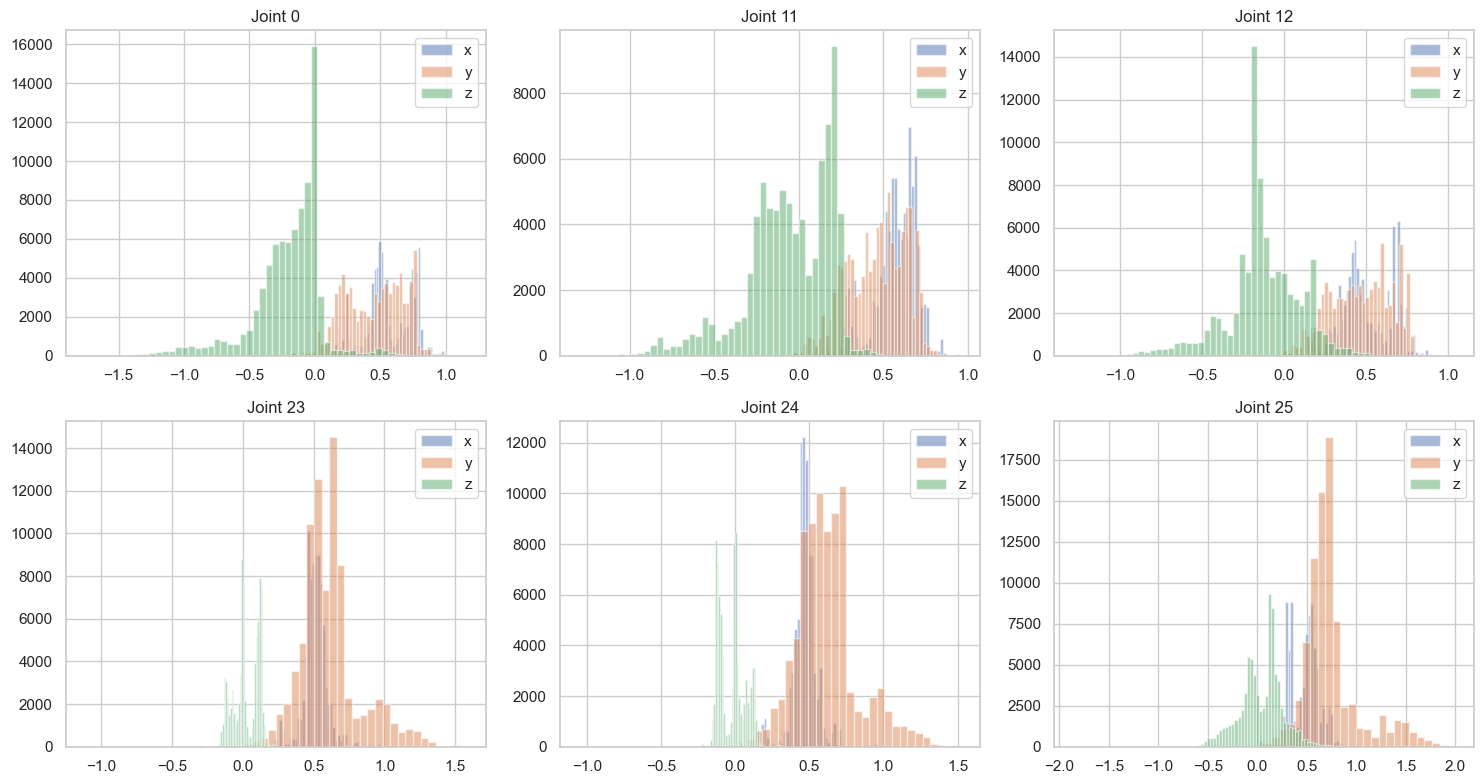

In [123]:
# I check the dimensions of the general dataset and compute basic statistics of the keypoint coordinates.
seq_len = X_gen.shape[1]
print(f"Fixed sequence length: {seq_len} frames")
print(f"Keypoint dimensionality: {X_gen.shape[2]} (33 landmarks × 3)")

# I flatten all keypoints to compute global min, max, mean, and standard deviation.
flat_kp = X_gen.reshape(-1, 99)
df_kp_stats = pd.DataFrame({
    'min': np.min(flat_kp, axis=0),
    'max': np.max(flat_kp, axis=0),
    'mean': np.mean(flat_kp, axis=0),
    'std': np.std(flat_kp, axis=0)
})
print("Global statistics of keypoints (x, y, z coordinates):")
display(df_kp_stats.describe())

# I plot histograms of the x, y, and z coordinates for a few selected landmarks.
# This helps me see the distribution of positions and detect any outliers.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
joints_to_plot = [0, 11, 12, 23, 24, 25]
for ax, j in zip(axes.flat, joints_to_plot):
    coords = flat_kp[:, j*3:j*3+3]
    ax.hist(coords[:, 0], alpha=0.5, label='x', bins=50)
    ax.hist(coords[:, 1], alpha=0.5, label='y', bins=50)
    ax.hist(coords[:, 2], alpha=0.5, label='z', bins=50)
    ax.set_title(f'Joint {j}')
    ax.legend()
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / "general_kp_distribution.png", dpi=120)
plt.show()

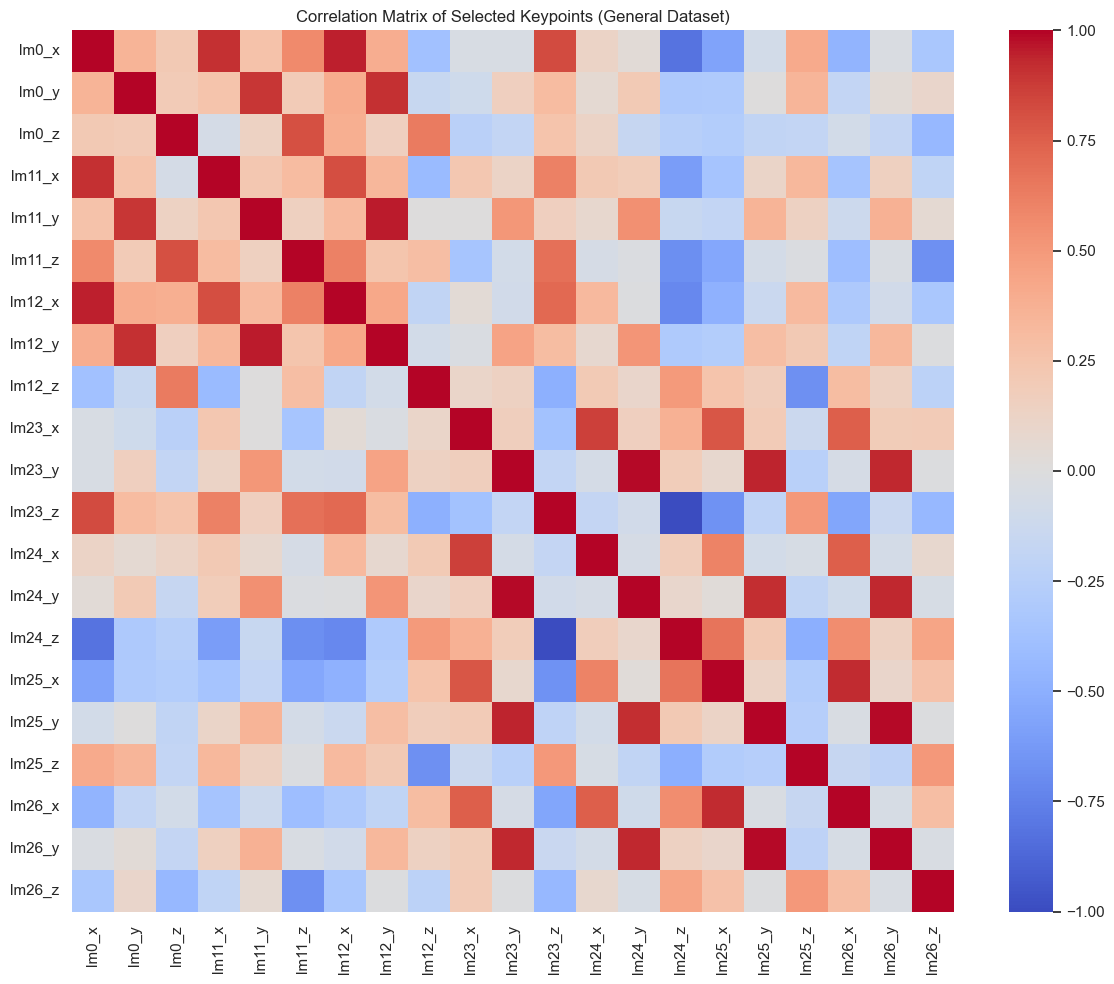

Top 10 absolute correlations (selected keypoints):


,feature_a,feature_b,corr
167,lm23_z,lm24_z,-0.999984
202,lm25_y,lm26_y,0.990480
157,lm23_y,lm24_y,0.986895
76,lm11_y,lm12_y,0.956775
5,lm0_x,lm12_x,0.947371
160,lm23_y,lm25_y,0.938779
163,lm23_y,lm26_y,0.936700
187,lm24_y,lm26_y,0.930307
197,lm25_x,lm26_x,0.922866
184,lm24_y,lm25_y,0.917213


In [124]:
# I compute the correlation matrix between selected keypoint coordinates.
# This helps me understand how the movements of different joints are related.
selected_landmarks = [0, 11, 12, 23, 24, 25, 26]
selected_dims = []
selected_names = []
for lm in selected_landmarks:
    selected_dims.extend([lm * 3 + 0, lm * 3 + 1, lm * 3 + 2])
    selected_names.extend([f"lm{lm}_x", f"lm{lm}_y", f"lm{lm}_z"])

# I take a random sample of frames to keep the correlation matrix computation fast.
sample_frames = flat_kp[np.random.choice(len(flat_kp), size=min(6000, len(flat_kp)), replace=False)]
kp_sel = sample_frames[:, selected_dims]
kp_corr_df = pd.DataFrame(kp_sel, columns=selected_names)
corr_kp = kp_corr_df.corr()

# I plot the correlation matrix as a heatmap.
plt.figure(figsize=(12, 10))
sns.heatmap(corr_kp, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Selected Keypoints (General Dataset)')
plt.tight_layout()
plt.savefig(EDA_FIG_DIR / 'general_keypoints_correlation.png', dpi=120)
plt.show()

# I extract the top 10 strongest correlations among the selected keypoints.
upper = corr_kp.where(np.triu(np.ones(corr_kp.shape), k=1).astype(bool))
strong_pairs = upper.stack().reset_index()
strong_pairs.columns = ['feature_a', 'feature_b', 'corr']
strong_pairs['abs_corr'] = strong_pairs['corr'].abs()
strong_pairs = strong_pairs.sort_values('abs_corr', ascending=False).head(10)

print('Top 10 absolute correlations (selected keypoints):')
display(strong_pairs[['feature_a', 'feature_b', 'corr']])

In [125]:
# I plot the hip Y-coordinate trajectories for all 8 general exercises.
# Each grey line represents one sample; the red line is the class average.
# This visualisation helps me see the characteristic movement pattern of each exercise.
fig = make_subplots(
    rows=2, cols=4,
    subplot_titles=EXERCISE_CLASSES,
    shared_yaxes=True,
    vertical_spacing=0.22,
    horizontal_spacing=0.12
)

rng = np.random.default_rng(RANDOM_SEED)

for i, cls in enumerate(EXERCISE_CLASSES):
    row = i // 4 + 1
    col = i % 4 + 1
    idx_cls = np.where(y_gen == i)[0]
    if len(idx_cls) == 0:
        continue
    sample_idx = rng.choice(idx_cls, min(10, len(idx_cls)), replace=False)
    for idx in sample_idx:
        seq = X_gen[idx]
        hip_y = seq[:, 23*3+1]
        time = np.arange(len(hip_y))
        fig.add_trace(
            go.Scatter(x=time, y=hip_y, mode='lines',
                       line=dict(width=1, color='gray'),
                       showlegend=False),
            row=row, col=col
        )
    idx_all = np.where(y_gen == i)[0]
    mean_hip_y = np.mean(X_gen[idx_all][:, :, 23*3+1], axis=0)
    fig.add_trace(
        go.Scatter(x=time, y=mean_hip_y, mode='lines',
                   line=dict(width=3, color='red'),
                   name=f'{cls} (average)'),
        row=row, col=col
    )
    fig.update_xaxes(title_text="Frame", title_font=dict(size=9), title_standoff=5,
                     row=row, col=col)
    fig.update_yaxes(title_text="Y Coordinate", title_font=dict(size=9), title_standoff=5,
                     row=row, col=col)

fig.update_layout(
    height=650,                              
    width=1100,                            
    title_text="Hip Trajectories (Y) - General Dataset",
    title_font=dict(size=14),
    margin=dict(t=100, b=60, l=60, r=60)
)

# I adjust the font size of the subplot titles for better readability.
for ann in fig['layout']['annotations']:
    ann['font'] = dict(size=9)

# I split long exercise names into two lines so they fit better in the subplot titles.
for ann in fig['layout']['annotations']:
    if len(ann['text']) > 15:
        if '_' in ann['text']:
            idx = ann['text'].find('_')
            ann['text'] = ann['text'][:idx] + '<br>' + ann['text'][idx+1:]
        else:
            ann['text'] = ann['text'][:10] + '<br>' + ann['text'][10:]

show_plot(fig, EDA_FIG_DIR / "general_trajectories.html")

In [126]:
# I define a function to convert a 99‑dimensional keypoint vector into 12 joint angles.
# These angles are the features I use for posture evaluation and explainable AI.
def landmarks_99_to_angles(keypoints_99):
    kp = np.array(keypoints_99).reshape(-1, 3)
    def p(idx): return kp[idx]
    def compute_angle(a, b, c):
        ba = a - b
        bc = c - b
        cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
        angle = np.arccos(np.clip(cosine, -1.0, 1.0))
        return np.degrees(angle)
    angles = []
    angles.append(compute_angle(p(23), p(25), p(27)))  # Left knee
    angles.append(compute_angle(p(24), p(26), p(28)))  # Right knee
    angles.append(compute_angle(p(11), p(23), p(25)))  # Left hip
    angles.append(compute_angle(p(12), p(24), p(26)))  # Right hip
    shoulder_mid = (p(11) + p(12)) / 2
    hip_mid = (p(23) + p(24)) / 2
    spine_vec = shoulder_mid - hip_mid
    vertical = np.array([0, 1, 0])
    spine_angle = np.degrees(np.arccos(np.clip(np.dot(spine_vec, vertical) / (np.linalg.norm(spine_vec)+1e-8), -1, 1)))
    angles.append(spine_angle)
    angles.append(compute_angle(p(13), p(11), p(23)))  # Left shoulder
    angles.append(compute_angle(p(14), p(12), p(24)))  # Right shoulder
    angles.append(compute_angle(p(11), p(13), p(15)))  # Left elbow
    angles.append(compute_angle(p(12), p(14), p(16)))  # Right elbow
    neck_vec = p(0) - shoulder_mid
    neck_angle = np.degrees(np.arccos(np.clip(np.dot(neck_vec, vertical) / (np.linalg.norm(neck_vec)+1e-8), -1, 1)))
    angles.append(neck_angle)
    angles.append(spine_angle)   # torso lean
    angles.append(neck_angle)    # head tilt
    return np.array(angles, dtype=np.float32)

ANGLE_NAMES = [
    "Left Knee", "Right Knee", "Left Hip", "Right Hip", "Spine",
    "Left Shoulder", "Right Shoulder", "Left Elbow", "Right Elbow",
    "Neck", "Torso Lean", "Head Tilt"
]

# I compute the joint angles for a sample of the general dataset and create box plots.
n_samples = min(2000, len(X_gen))
indices = np.random.choice(len(X_gen), n_samples, replace=False)
X_sample = X_gen[indices]
y_sample = y_gen[indices]

angle_list = []
for i in tqdm(range(n_samples), desc="Calculating angles"):
    seq = X_sample[i]
    angles_frame = [landmarks_99_to_angles(seq[t]) for t in range(seq.shape[0])]
    mean_angles = np.mean(angles_frame, axis=0)
    angle_list.append(mean_angles)

df_angles_gen = pd.DataFrame(angle_list, columns=ANGLE_NAMES)
df_angles_gen['class'] = y_sample
df_angles_gen['class_name'] = df_angles_gen['class'].apply(lambda i: EXERCISE_CLASSES[i])

fig = px.box(df_angles_gen.melt(id_vars=['class_name'], value_vars=ANGLE_NAMES),
             x='variable', y='value', color='class_name',
             title='Joint Angle Distribution by Class - General Dataset')
fig.update_xaxes(tickangle=45)
show_plot(fig, EDA_FIG_DIR / "general_angles_box.html")
df_angles_gen.to_csv(EDA_FIG_DIR / "general_angles_sample.csv", index=False)

Calculating angles: 100%|██████████| 2000/2000 [00:06<00:00, 313.73it/s]


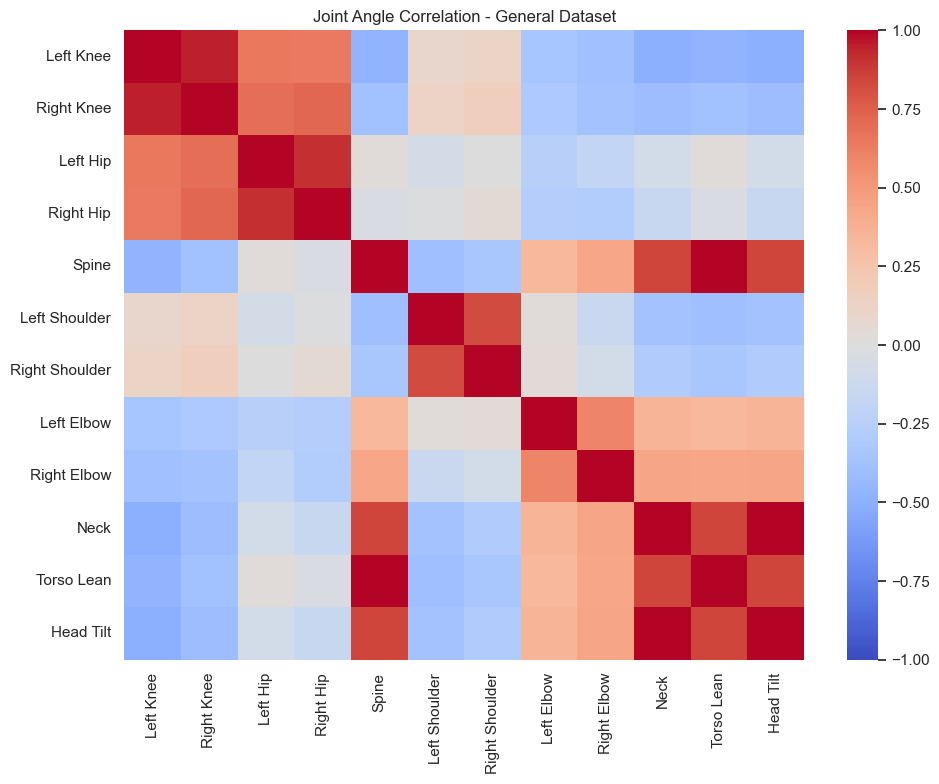

Angle pairs with highest absolute correlation (General Dataset):


,angle_a,angle_b,corr
43,Spine,Torso Lean,1.000000
64,Neck,Head Tilt,1.000000
0,Left Knee,Right Knee,0.950465
21,Left Hip,Right Hip,0.910179
63,Neck,Torso Lean,0.848574
42,Spine,Neck,0.848574
65,Torso Lean,Head Tilt,0.848574
44,Spine,Head Tilt,0.848574


In [127]:
# I compute the correlation matrix of the joint angles for the general dataset.
# This shows me which angles tend to move together and which are independent.
if 'df_angles_gen' in globals() and not df_angles_gen.empty:
    corr_angles_gen = df_angles_gen[ANGLE_NAMES].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_angles_gen, cmap='coolwarm', center=0, vmin=-1, vmax=1, annot=False)
    plt.title('Joint Angle Correlation - General Dataset')
    plt.tight_layout()
    plt.savefig(EDA_FIG_DIR / 'general_angles_correlation.png', dpi=120)
    plt.show()

    # I extract the pairs of angles with the strongest absolute correlation.
    upper = corr_angles_gen.where(np.triu(np.ones(corr_angles_gen.shape), k=1).astype(bool))
    top_corr = upper.stack().reset_index()
    top_corr.columns = ['angle_a', 'angle_b', 'corr']
    top_corr['abs_corr'] = top_corr['corr'].abs()
    top_corr = top_corr.sort_values('abs_corr', ascending=False).head(8)

    print('Angle pairs with highest absolute correlation (General Dataset):')
    display(top_corr[['angle_a', 'angle_b', 'corr']])

In [128]:
# I now load the rehabilitation dataset, which contains 10 exercise classes.
# I try the MediaPipe version first; if it fails, I fall back to the Kinect version.
print("Loading rehabilitation dataset (10 classes)...")

rehab_classes = [
    "arm_circle", "forward_lunge", "high_knee_raise", "hip_abduction",
    "leg_extension", "shoulder_abduction", "shoulder_external_rotation",
    "shoulder_flexion", "side_step_squat", "squat"
]

try:
    rehab_loaded = load_execheck_rehab_mediapipe(force_reprocess=False)
    if len(rehab_loaded) == 3:
        X_rehab, y_rehab, _ = rehab_loaded
    else:
        X_rehab, y_rehab = rehab_loaded
    source = "MediaPipe"
except Exception as e:
    print(f"MediaPipe is not available ({e}), trying with Kinect...")
    from src.computer_vision.exercise_classifier_rehab import load_kinect_data
    rehab_loaded = load_kinect_data(force_reprocess=False)
    if len(rehab_loaded) == 3:
        X_rehab, y_rehab, _ = rehab_loaded
    else:
        X_rehab, y_rehab = rehab_loaded
    source = "Kinect"

print(f"Rehabilitation dataset ({source}) loaded:")
print(f"  - X shape: {X_rehab.shape}")
print(f"  - y shape: {y_rehab.shape}")
print(f"  - Classes: {rehab_classes}")

Loading rehabilitation dataset (10 classes)...
[DataLoader] Loading cached MediaPipe dataset...
  X: (1000, 30, 99), y: (1000,)
Rehabilitation dataset (MediaPipe) loaded:
  - X shape: (1000, 30, 99)
  - y shape: (1000,)
  - Classes: ['arm_circle', 'forward_lunge', 'high_knee_raise', 'hip_abduction', 'leg_extension', 'shoulder_abduction', 'shoulder_external_rotation', 'shoulder_flexion', 'side_step_squat', 'squat']


In [129]:
# I plot the class distribution of the rehabilitation dataset.
# This bar chart shows how many samples I have for each of the 10 rehabilitation exercises.
counts_rehab = pd.Series(y_rehab).value_counts().sort_index()
labels_rehab = [rehab_classes[i] for i in counts_rehab.index]
source_label = globals().get('source', 'unknown')

df_rehab_dist = pd.DataFrame({
    'Class': labels_rehab,
    'samples': counts_rehab.values,
})
df_rehab_dist['Percentage'] = df_rehab_dist['samples'] / len(y_rehab) * 100

fig = px.bar(
    df_rehab_dist,
    x='Class',
    y='samples',
    text='samples',
    labels={'Class': 'Exercise Class', 'samples': 'Number of Samples'},
    title=f'Distribution of Classes - Rehabilitation Dataset ({source_label})',
    color='Class',
    color_discrete_sequence=px.colors.qualitative.Set3
)
fig.update_traces(textposition='outside')
show_plot(fig, EDA_FIG_DIR / "rehab_class_dist.html")

display(df_rehab_dist)

,Class,samples,Percentage
0,arm_circle,100,10.0
1,forward_lunge,100,10.0
2,high_knee_raise,100,10.0
3,hip_abduction,100,10.0
4,leg_extension,100,10.0
5,shoulder_abduction,100,10.0
6,shoulder_external_rotation,100,10.0
7,shoulder_flexion,100,10.0
8,side_step_squat,100,10.0
9,squat,100,10.0


In [130]:
# I check the class balance of the rehabilitation dataset.
# I compute the ratio between the largest and smallest class to see how balanced it is.
if 'df_rehab_dist' in globals() and not df_rehab_dist.empty:
    max_row = df_rehab_dist.sort_values('samples', ascending=False).iloc[0]
    min_row = df_rehab_dist.sort_values('samples', ascending=True).iloc[0]
    imbalance_ratio = max_row['samples'] / max(min_row['samples'], 1)

    print(f"Majority rehab class: {max_row['Class']} ({int(max_row['samples'])} samples)")
    print(f"Minority rehab class: {min_row['Class']} ({int(min_row['samples'])} samples)")
    print(f"Rehab max/min imbalance ratio: {imbalance_ratio:.2f}")

    if imbalance_ratio <= 1.2:
        print('[Conclusion] The rehabilitation dataset is very well balanced across classes.')
    elif imbalance_ratio <= 2.0:
        print('[Conclusion] The rehab dataset has moderate imbalance, manageable with light class weights.')
    else:
        print('[Conclusion] The rehab dataset shows high imbalance; resampling and stratified validation are recommended.')

Majority rehab class: arm_circle (100 samples)
Minority rehab class: arm_circle (100 samples)
Rehab max/min imbalance ratio: 1.00
[Conclusion] The rehabilitation dataset is very well balanced across classes.


In [131]:
source_label = globals().get('source', 'unknown')

fig = make_subplots(rows=3, cols=4, subplot_titles=rehab_classes,
                    shared_yaxes=True, vertical_spacing=0.08)
rng = np.random.default_rng(RANDOM_SEED)

for i, cls in enumerate(rehab_classes):
    row = i // 4 + 1
    col = i % 4 + 1
    idx_cls = np.where(y_rehab == i)[0]
    if len(idx_cls) == 0:
        continue
    sample_idx = rng.choice(idx_cls, min(8, len(idx_cls)), replace=False)
    for idx in sample_idx:
        seq = X_rehab[idx]
        if X_rehab.shape[2] == 99:
            hip_y = seq[:, 23*3+1]
        else:
            hip_y = seq[:, 12*3+1]  # Kinect
        time = np.arange(len(hip_y))
        fig.add_trace(go.Scatter(x=time, y=hip_y, mode='lines',
                                 line=dict(width=1, color='gray'),
                                 showlegend=False),
                      row=row, col=col)
    idx_all = np.where(y_rehab == i)[0]
    if X_rehab.shape[2] == 99:
        mean_hip_y = np.mean(X_rehab[idx_all][:, :, 23*3+1], axis=0)
    else:
        mean_hip_y = np.mean(X_rehab[idx_all][:, :, 12*3+1], axis=0)
    fig.add_trace(go.Scatter(x=time, y=mean_hip_y, mode='lines',
                             line=dict(width=3, color='red'),
                             name=f'{cls} (average)'),
                  row=row, col=col)
    fig.update_xaxes(title_text="Frame", row=row, col=col)
    fig.update_yaxes(title_text="Y Coordinate", row=row, col=col)

fig.update_layout(height=800, title_text=f"Hip Trajectories (Y) - Rehabilitation Dataset ({source_label})")
show_plot(fig, EDA_FIG_DIR / "rehab_trajectories.html")

In [132]:
if X_rehab.shape[2] == 99:
    n_samples_rehab = min(1000, len(X_rehab))
    indices = np.random.choice(len(X_rehab), n_samples_rehab, replace=False)
    X_sample_rehab = X_rehab[indices]
    y_sample_rehab = y_rehab[indices]
    angle_list_rehab = []
    for i in tqdm(range(n_samples_rehab), desc="Calculating rehab angles"):
        seq = X_sample_rehab[i]
        angles_frame = [landmarks_99_to_angles(seq[t]) for t in range(seq.shape[0])]
        mean_angles = np.mean(angles_frame, axis=0)
        angle_list_rehab.append(mean_angles)
    df_angles_rehab = pd.DataFrame(angle_list_rehab, columns=ANGLE_NAMES)
    df_angles_rehab['class'] = y_sample_rehab
    df_angles_rehab['class_name'] = df_angles_rehab['class'].apply(lambda i: rehab_classes[i])
    fig = px.box(df_angles_rehab.melt(id_vars=['class_name'], value_vars=ANGLE_NAMES),
                 x='variable', y='value', color='class_name',
                 title='Joint Angle Distribution by Class - Rehabilitation Dataset')
    fig.update_xaxes(tickangle=45)
    show_plot(fig, EDA_FIG_DIR / "rehab_angles_box.html")
else:
    print("Rehab dataset does not have 99 dimensions (Kinect), skipping angle calculation.")

Calculating rehab angles: 100%|██████████| 1000/1000 [00:03<00:00, 265.56it/s]


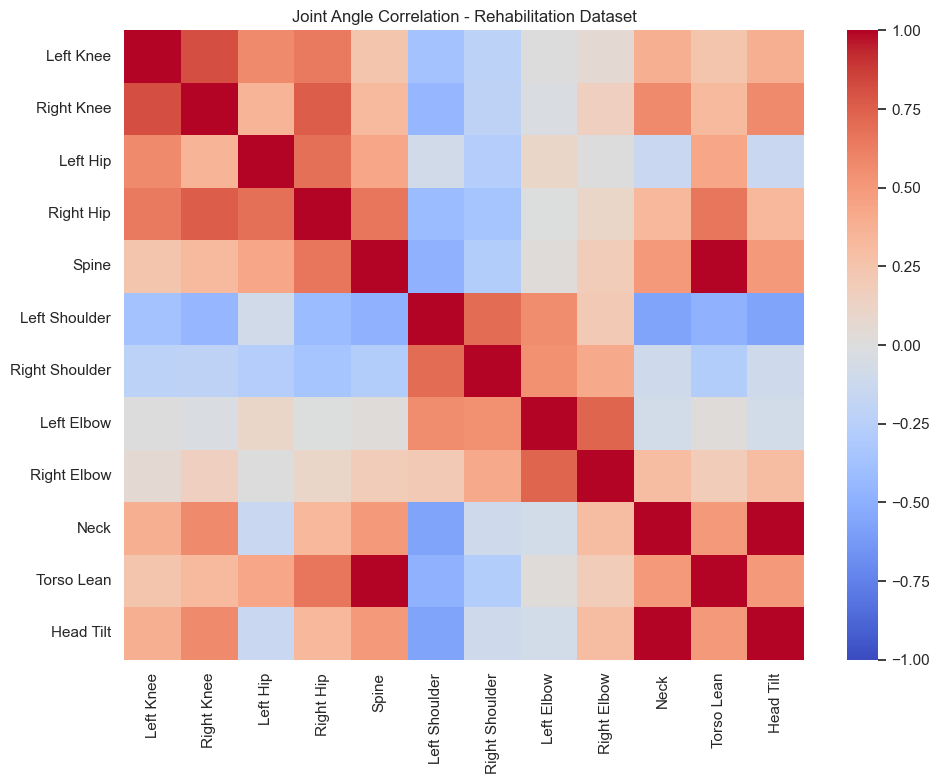

Angle pairs with highest absolute correlation (Rehabilitation Dataset):


,angle_a,angle_b,corr
43,Spine,Torso Lean,1.000000
64,Neck,Head Tilt,1.000000
0,Left Knee,Right Knee,0.817549
12,Right Knee,Right Hip,0.759079
56,Left Elbow,Right Elbow,0.728896
45,Left Shoulder,Right Shoulder,0.698584
21,Left Hip,Right Hip,0.687078
30,Right Hip,Spine,0.661219


In [133]:
# I compute the correlation matrix of the joint angles for the rehabilitation dataset.
# This helps me understand the relationships between different joint movements in rehab exercises.
if 'df_angles_rehab' in globals() and not df_angles_rehab.empty:
    corr_angles_rehab = df_angles_rehab[ANGLE_NAMES].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_angles_rehab, cmap='coolwarm', center=0, vmin=-1, vmax=1, annot=False)
    plt.title('Joint Angle Correlation - Rehabilitation Dataset')
    plt.tight_layout()
    plt.savefig(EDA_FIG_DIR / 'rehab_angles_correlation.png', dpi=120)
    plt.show()

    # I extract the pairs of angles with the strongest absolute correlation.
    upper = corr_angles_rehab.where(np.triu(np.ones(corr_angles_rehab.shape), k=1).astype(bool))
    top_corr = upper.stack().reset_index()
    top_corr.columns = ['angle_a', 'angle_b', 'corr']
    top_corr['abs_corr'] = top_corr['corr'].abs()
    top_corr = top_corr.sort_values('abs_corr', ascending=False).head(8)

    print('Angle pairs with highest absolute correlation (Rehabilitation Dataset):')
    display(top_corr[['angle_a', 'angle_b', 'corr']])
else:
    print('I do not have df_angles_rehab available (for example, if rehab is not in 99‑dim format).')

In [134]:
try:
    df_rep = load_repcount_annotations('test')
    print(f"RepCountA (test) annotations loaded: {len(df_rep)} segments")
    
    fig1 = px.histogram(df_rep, x='reps', nbins=20,
                        title='Distribution of Repetition Counts (RepCountA test)')
    show_plot(fig1, EDA_FIG_DIR / "repcount_reps_dist.html")
    
    class_counts = df_rep['exercise'].value_counts()
    fig2 = px.bar(x=class_counts.index, y=class_counts.values,
                  labels={'x':'exercise', 'y':'number of segments'},
                  title='Segments per Class in RepCountA')
    show_plot(fig2, EDA_FIG_DIR / "repcount_class_counts.html")
    
    display(df_rep.describe())
except FileNotFoundError as e:
    print(e)

RepCountA (test) annotations loaded: 152 segments


,Unnamed: 0,reps,L1,L2,L3,L4,L5,L6,L7,L8,...,L293,L294,L295,L296,L297,L298,L299,L300,L301,L302
count,152.000000,152.000000,151.000000,151.000000,148.000000,148.000000,139.000000,139.00000,127.000000,127.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,75.500000,16.223684,64.437086,128.874172,132.790541,193.722973,194.640288,251.52518,254.897638,308.204724,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,44.022721,15.559839,110.983457,130.549776,141.880004,168.645779,190.722843,211.64358,223.554043,247.747226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,7.000000,8.000000,11.000000,11.000000,14.00000,14.000000,18.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,37.750000,5.000000,8.500000,52.500000,52.750000,88.000000,86.000000,118.00000,117.500000,144.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,75.500000,10.500000,30.000000,90.000000,89.500000,132.500000,132.000000,183.00000,174.000000,222.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,113.250000,26.250000,61.500000,143.000000,142.500000,241.500000,212.000000,294.00000,289.500000,356.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,151.000000,92.000000,726.000000,790.000000,791.000000,959.000000,1293.000000,1363.00000,1363.000000,1417.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [135]:
# I compute summary statistics for the repetition counts in the RepCountA test set.
# This helps me understand the variability and distribution of the ground truth.
if 'df_rep' in globals() and not df_rep.empty and 'reps' in df_rep.columns:
    reps_num = pd.to_numeric(df_rep['reps'], errors='coerce').dropna()
    q = reps_num.quantile([0.25, 0.5, 0.75]).to_dict()
    print(f"Reps - mean: {reps_num.mean():.2f}, median: {q[0.5]:.2f}, IQR: [{q[0.25]:.2f}, {q[0.75]:.2f}]")

    if 'exercise' in df_rep.columns:
        per_ex = df_rep['exercise'].value_counts()
        print('Top 10 exercises by number of segments (RepCountA):')
        display(per_ex.head(10).rename('segments').to_frame())

    # I interpret the variability to decide whether robust counting models are needed.
    if reps_num.std() > reps_num.mean() * 0.7:
        print('[Conclusion] High variability in repetitions. I recommend evaluating counting models that are robust to amplitude and rhythm.')
    else:
        print('[Conclusion] Moderate variability in repetitions. The dataset is favorable for supervised counting models.')

Reps - mean: 16.22, median: 10.50, IQR: [5.00, 26.25]
Top 10 exercises by number of segments (RepCountA):


,segments
exercise,
jump_jack,23
situp,20
pull_up,16
bench_pressing,16
pommelhorse,15
push_up,14
front_raise,14
squat,13
squant,5


[Conclusion] High variability in repetitions. I recommend evaluating counting models that are robust to amplitude and rhythm.


In [136]:
# I create a grouped bar chart comparing the number of samples per class in the
# general and rehabilitation datasets. This helps me see which classes are well
# represented and which might need more data or augmentation.
balance_data = []
for i, cls in enumerate(EXERCISE_CLASSES):
    balance_data.append({'Dataset': 'General', 'Class': cls, 'samples': np.sum(y_gen == i)})
for i, cls in enumerate(rehab_classes):
    balance_data.append({'Dataset': 'Rehab', 'Class': cls, 'samples': np.sum(y_rehab == i)})

df_balance = pd.DataFrame(balance_data)
fig = px.bar(df_balance, x='Class', y='samples', color='Dataset', barmode='group',
             title='Comparison of Samples per Class Between Datasets')
fig.update_xaxes(tickangle=45)
show_plot(fig, EDA_FIG_DIR / "class_balance_comparison.html")

In [137]:
# I define helper functions to compute percentages and safely cast to float.
from pathlib import Path

def _pct(n, d):
    return (100.0 * n / d) if d else 0.0

def _safe_float(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return default

# I collect the main quantitative metrics from the EDA into a dictionary.
metrics = {}

# Overall data volume and top‑3 source concentration.
if 'df_source_summary' in globals() and isinstance(df_source_summary, pd.DataFrame) and not df_source_summary.empty:
    total_global = int(df_source_summary['total'].sum())
    top3_total = int(df_source_summary.head(3)['total'].sum())
    top3_share = _pct(top3_total, total_global)
    metrics['total_global'] = total_global
    metrics['top3_total'] = top3_total
    metrics['top3_share_pct'] = top3_share
else:
    metrics['total_global'] = np.nan
    metrics['top3_total'] = np.nan
    metrics['top3_share_pct'] = np.nan

# General dataset class imbalance.
if 'df_gen_dist' in globals() and isinstance(df_gen_dist, pd.DataFrame) and not df_gen_dist.empty:
    gmax = float(df_gen_dist['samples'].max())
    gmin = float(df_gen_dist['samples'].min())
    metrics['general_imbalance_ratio'] = gmax / max(gmin, 1.0)
else:
    metrics['general_imbalance_ratio'] = np.nan

# Rehabilitation dataset class imbalance.
if 'df_rehab_dist' in globals() and isinstance(df_rehab_dist, pd.DataFrame) and not df_rehab_dist.empty:
    rmax = float(df_rehab_dist['samples'].max())
    rmin = float(df_rehab_dist['samples'].min())
    metrics['rehab_imbalance_ratio'] = rmax / max(rmin, 1.0)
else:
    metrics['rehab_imbalance_ratio'] = np.nan

# Ratio of incorrect to correct posture samples.
if 'df_correction_summary' in globals() and isinstance(df_correction_summary, pd.DataFrame) and not df_correction_summary.empty:
    corr_total = float(df_correction_summary['total_samples'].sum())
    corr_incorrect = float(df_correction_summary['incorrect_samples'].sum())
    metrics['incorrect_ratio_pct'] = _pct(corr_incorrect, corr_total)
    metrics['correction_total_samples'] = int(corr_total)
else:
    metrics['incorrect_ratio_pct'] = np.nan
    metrics['correction_total_samples'] = np.nan

# Repetition count statistics from RepCountA.
if 'df_rep' in globals() and isinstance(df_rep, pd.DataFrame) and not df_rep.empty and 'reps' in df_rep.columns:
    reps_num = pd.to_numeric(df_rep['reps'], errors='coerce').dropna()
    if len(reps_num) > 0:
        metrics['reps_mean'] = float(reps_num.mean())
        metrics['reps_std'] = float(reps_num.std())
        metrics['reps_cv'] = float(reps_num.std() / (reps_num.mean() + 1e-8))
    else:
        metrics['reps_mean'] = np.nan
        metrics['reps_std'] = np.nan
        metrics['reps_cv'] = np.nan
else:
    metrics['reps_mean'] = np.nan
    metrics['reps_std'] = np.nan
    metrics['reps_cv'] = np.nan

# I create a table summarising the threats to validity identified during the EDA.
validity_rows = []

top3_share = _safe_float(metrics.get('top3_share_pct'))
if np.isnan(top3_share):
    sev_source = 'undetermined'
elif top3_share >= 80:
    sev_source = 'high'
elif top3_share >= 60:
    sev_source = 'medium'
else:
    sev_source = 'low'

validity_rows.append({
    'threat': 'Dominant source bias',
    'severity': sev_source,
    'numeric_evidence': f"Top‑3 sources = {top3_share:.2f}% of total" if not np.isnan(top3_share) else 'Not available in memory',
    'methodological_note': 'Complement with source‑stratified validation to measure true generalization.'
})

gen_imb = _safe_float(metrics.get('general_imbalance_ratio'))
rehab_imb = _safe_float(metrics.get('rehab_imbalance_ratio'))
validity_rows.append({
    'threat': 'Class imbalance (general and rehab)',
    'severity': 'medium' if (not np.isnan(gen_imb) and gen_imb > 2) else 'low',
    'numeric_evidence': f"General max/min = {gen_imb:.2f}; Rehab max/min = {rehab_imb:.2f}" if (not np.isnan(gen_imb) and not np.isnan(rehab_imb)) else 'Not available in memory',
    'methodological_note': 'Maintain macro metrics and use loss weighting when applicable.'
})

validity_rows.append({
    'threat': 'Technical heterogeneity across datasets (camera/frame‑rate/environment)',
    'severity': 'medium',
    'numeric_evidence': 'Multiple acquisition sources and formats in the integrated EDA',
    'methodological_note': 'Check domain robustness and report performance per source.'
})

candidate_group_cols = ['subject_id', 'subject', 'session_id', 'session', 'video_id', 'video', 'video_name']
available_group_cols = []
if 'df_rep' in globals() and isinstance(df_rep, pd.DataFrame):
    available_group_cols = [c for c in candidate_group_cols if c in df_rep.columns]

leak_sev = 'medium' if len(available_group_cols) == 0 else 'controllable'
leak_evidence = (
    f"Grouping columns detected in RepCountA: {available_group_cols}"
    if available_group_cols
    else 'I did not detect explicit subject/session/video columns in the active table.'
)

validity_rows.append({
    'threat': 'Possible leakage due to subject/video in the split',
    'severity': leak_sev,
    'numeric_evidence': leak_evidence,
    'methodological_note': 'Apply group‑based splits when metadata allows; otherwise, fall back to video/source grouping.'
})

df_validity = pd.DataFrame(validity_rows)
print('Formal threats to validity:')
display(df_validity)

# I propose an explicit split protocol to avoid data leakage.
protocol_rows = [
    {
        'priority': 1,
        'group_field': 'subject_id',
        'use_if_available': 'Yes',
        'anti_leakage_reason': 'Prevents sharing the same person identity across train/val/test.'
    },
    {
        'priority': 2,
        'group_field': 'session_id',
        'use_if_available': 'Yes',
        'anti_leakage_reason': 'Prevents temporal leakage within the same capture session.'
    },
    {
        'priority': 3,
        'group_field': 'video_id / video_name',
        'use_if_available': 'Yes',
        'anti_leakage_reason': 'Prevents segments from the same video from appearing in more than one split.'
    },
    {
        'priority': 4,
        'group_field': 'source + class',
        'use_if_available': 'Fallback',
        'anti_leakage_reason': 'Useful when fine metadata is missing; reduces mixing across domains.'
    },
]
df_split_protocol = pd.DataFrame(protocol_rows)

print('\nRecommended explicit split protocol:')
display(df_split_protocol)

if available_group_cols:
    print(f"Fields currently detected for grouping: {available_group_cols}")
else:
    print('I do not detect explicit grouping columns in the active table, so I will use a video/source fallback when possible.')

# I build a table of modelling decisions derived directly from the EDA findings.
decision_rows = []

decision_rows.append({
    'detected_risk': 'Source concentration',
    'numeric_evidence': f"Top‑3 share = {top3_share:.2f}%" if not np.isnan(top3_share) else 'Not available',
    'concrete_training_action': 'Train with stratified sampling by source and class_weight.',
    'concrete_evaluation_action': 'Report global metrics and per‑source metrics (macro‑F1, balanced accuracy).',
})

if not np.isnan(gen_imb):
    decision_rows.append({
        'detected_risk': 'Imbalance in general classes',
        'numeric_evidence': f"Max/min ratio General = {gen_imb:.2f}",
        'concrete_training_action': 'Use class weights and/or focal loss in the general classifier.',
        'concrete_evaluation_action': 'Prioritise macro‑F1 and per‑class confusion matrices.',
    })

if not np.isnan(rehab_imb):
    decision_rows.append({
        'detected_risk': 'Balance in rehab classes',
        'numeric_evidence': f"Max/min ratio Rehab = {rehab_imb:.2f}",
        'concrete_training_action': 'Keep base configuration; adjust weights only if distribution changes.',
        'concrete_evaluation_action': 'Compare macro vs. micro metrics to confirm stability.',
    })

inc_ratio = _safe_float(metrics.get('incorrect_ratio_pct'))
corr_total = metrics.get('correction_total_samples', np.nan)
if not np.isnan(inc_ratio):
    decision_rows.append({
        'detected_risk': 'Correct/incorrect distribution in execution quality',
        'numeric_evidence': f"Incorrect ratio = {inc_ratio:.2f}% over {int(corr_total)} samples",
        'concrete_training_action': 'Calibrate threshold and consider cost‑sensitive loss per exercise.',
        'concrete_evaluation_action': 'Report precision/recall/F1 for the incorrect class per exercise.',
    })

reps_cv = _safe_float(metrics.get('reps_cv'))
if not np.isnan(reps_cv):
    decision_rows.append({
        'detected_risk': 'Repetition variability (RepCountA)',
        'numeric_evidence': f"CV of reps = {reps_cv:.2f}",
        'concrete_training_action': 'Use counting models robust to rhythm and amplitude.',
        'concrete_evaluation_action': 'Break down MAE/RMSE by exercise and by repetition range.',
    })

decision_rows.append({
    'detected_risk': 'Possible split leakage',
    'numeric_evidence': leak_evidence,
    'concrete_training_action': 'Create group‑based splits (subject/session/video) in priority order.',
    'concrete_evaluation_action': 'Verify no group overlap between train/val/test.',
})

df_modeling_decisions = pd.DataFrame(decision_rows)
print('\nModelling decisions table derived from the EDA:')
display(df_modeling_decisions)

# I export the three key tables (threats, split protocol, modelling decisions) as CSV files.
out_dir = EDA_FIG_DIR / 'tables'
out_dir.mkdir(parents=True, exist_ok=True)
df_validity.to_csv(out_dir / 'eda_threats_to_validity.csv', index=False)
df_split_protocol.to_csv(out_dir / 'eda_split_protocol.csv', index=False)
df_modeling_decisions.to_csv(out_dir / 'eda_modeling_decisions.csv', index=False)

print('\nExported:')
print(f"- {out_dir / 'eda_threats_to_validity.csv'}")
print(f"- {out_dir / 'eda_split_protocol.csv'}")
print(f"- {out_dir / 'eda_modeling_decisions.csv'}")

Formal threats to validity:


,threat,severity,numeric_evidence,methodological_note
0,Dominant source bias,high,Top‑3 sources = 99.29% of total,Complement with source‑stratified validation t...
1,Class imbalance (general and rehab),medium,General max/min = 29.42; Rehab max/min = 1.00,Maintain macro metrics and use loss weighting ...
2,Technical heterogeneity across datasets (camer...,medium,Multiple acquisition sources and formats in th...,Check domain robustness and report performance...
3,Possible leakage due to subject/video in the s...,controllable,Grouping columns detected in RepCountA: ['video'],Apply group‑based splits when metadata allows;...



Recommended explicit split protocol:


,priority,group_field,use_if_available,anti_leakage_reason
0,1,subject_id,Yes,Prevents sharing the same person identity acro...
1,2,session_id,Yes,Prevents temporal leakage within the same capt...
2,3,video_id / video_name,Yes,Prevents segments from the same video from app...
3,4,source + class,Fallback,Useful when fine metadata is missing; reduces ...


Fields currently detected for grouping: ['video']

Modelling decisions table derived from the EDA:


,detected_risk,numeric_evidence,concrete_training_action,concrete_evaluation_action
0,Source concentration,Top‑3 share = 99.29%,Train with stratified sampling by source and c...,Report global metrics and per‑source metrics (...
1,Imbalance in general classes,Max/min ratio General = 29.42,Use class weights and/or focal loss in the gen...,Prioritise macro‑F1 and per‑class confusion ma...
2,Balance in rehab classes,Max/min ratio Rehab = 1.00,Keep base configuration; adjust weights only i...,Compare macro vs. micro metrics to confirm sta...
3,Correct/incorrect distribution in execution qu...,Incorrect ratio = 50.15% over 5396 samples,Calibrate threshold and consider cost‑sensitiv...,Report precision/recall/F1 for the incorrect c...
4,Repetition variability (RepCountA),CV of reps = 0.96,Use counting models robust to rhythm and ampli...,Break down MAE/RMSE by exercise and by repetit...
5,Possible split leakage,Grouping columns detected in RepCountA: ['video'],Create group‑based splits (subject/session/vid...,Verify no group overlap between train/val/test.



Exported:
- c:\FitCoachProj\models\plots\eda_notebook\tables\eda_threats_to_validity.csv
- c:\FitCoachProj\models\plots\eda_notebook\tables\eda_split_protocol.csv
- c:\FitCoachProj\models\plots\eda_notebook\tables\eda_modeling_decisions.csv


In [138]:
# I perform a series of final validation checks to ensure the data is consistent.
validation_checks = []

# Check that the general dataset features and labels are defined.
validation_checks.append({
    'check': 'General: X and y defined',
    'status': 'OK' if ('X_gen' in globals() and 'y_gen' in globals()) else 'ERROR',
    'detail': f"X_gen shape={getattr(X_gen, 'shape', None)}, y_gen shape={getattr(y_gen, 'shape', None)}"
})

if 'X_gen' in globals() and 'y_gen' in globals():
    same_len = len(X_gen) == len(y_gen)
    validation_checks.append({
        'check': 'General: len(X) == len(y)',
        'status': 'OK' if same_len else 'ERROR',
        'detail': f"len(X_gen)={len(X_gen)}, len(y_gen)={len(y_gen)}"
    })

    class_total_general = int(pd.Series(y_gen).value_counts().sum())
    validation_checks.append({
        'check': 'General: class sum equals total',
        'status': 'OK' if class_total_general == len(y_gen) else 'ERROR',
        'detail': f"class_sum={class_total_general}, total={len(y_gen)}"
    })

# Check that the rehabilitation dataset features and labels are defined.
validation_checks.append({
    'check': 'Rehab: X and y defined',
    'status': 'OK' if ('X_rehab' in globals() and 'y_rehab' in globals()) else 'ERROR',
    'detail': f"X_rehab shape={getattr(X_rehab, 'shape', None)}, y_rehab shape={getattr(y_rehab, 'shape', None)}"
})

if 'X_rehab' in globals() and 'y_rehab' in globals():
    same_len_rehab = len(X_rehab) == len(y_rehab)
    validation_checks.append({
        'check': 'Rehab: len(X) == len(y)',
        'status': 'OK' if same_len_rehab else 'ERROR',
        'detail': f"len(X_rehab)={len(X_rehab)}, len(y_rehab)={len(y_rehab)}"
    })

    class_total_rehab = int(pd.Series(y_rehab).value_counts().sum())
    validation_checks.append({
        'check': 'Rehab: class sum equals total',
        'status': 'OK' if class_total_rehab == len(y_rehab) else 'ERROR',
        'detail': f"class_sum={class_total_rehab}, total={len(y_rehab)}"
    })

# Check that the source summary DataFrame is not empty.
if 'df_source_summary' in globals():
    validation_checks.append({
        'check': 'Source summary not empty',
        'status': 'OK' if not df_source_summary.empty else 'WARNING',
        'detail': f"rows={len(df_source_summary)}"
    })

# Check that the correction summary DataFrame is available.
if 'df_correction_summary' in globals():
    validation_checks.append({
        'check': 'Correction summary available',
        'status': 'OK' if not df_correction_summary.empty else 'WARNING',
        'detail': f"rows={len(df_correction_summary)}"
    })

# Check the RepCountA data for the presence and validity of the 'reps' column.
if 'df_rep' in globals():
    has_reps = 'reps' in df_rep.columns
    validation_checks.append({
        'check': 'RepCountA: reps column present',
        'status': 'OK' if has_reps else 'ERROR',
        'detail': f"columns={list(df_rep.columns)}"
    })

    if has_reps:
        validation_checks.append({
            'check': 'RepCountA: valid reps values',
            'status': 'OK' if pd.to_numeric(df_rep['reps'], errors='coerce').notna().all() else 'WARNING',
            'detail': f"n_segments={len(df_rep)}"
        })

validation_df = pd.DataFrame(validation_checks)
display(validation_df)

validation_out = EDA_FIG_DIR / 'tables' / 'eda_validation_checks.csv'
validation_out.parent.mkdir(parents=True, exist_ok=True)
validation_df.to_csv(validation_out, index=False)
print(f"Validation checks saved to: {validation_out}")

,check,status,detail
0,General: X and y defined,OK,"X_gen shape=(2750, 30, 99), y_gen shape=(2750,)"
1,General: len(X) == len(y),OK,"len(X_gen)=2750, len(y_gen)=2750"
2,General: class sum equals total,OK,"class_sum=2750, total=2750"
3,Rehab: X and y defined,OK,"X_rehab shape=(1000, 30, 99), y_rehab shape=(1..."
4,Rehab: len(X) == len(y),OK,"len(X_rehab)=1000, len(y_rehab)=1000"
5,Rehab: class sum equals total,OK,"class_sum=1000, total=1000"
6,Source summary not empty,OK,rows=6
7,Correction summary available,OK,rows=20
8,RepCountA: reps column present,OK,"columns=['Unnamed: 0', 'exercise', 'video', 'r..."
9,RepCountA: valid reps values,OK,n_segments=152


Validation checks saved to: c:\FitCoachProj\models\plots\eda_notebook\tables\eda_validation_checks.csv
